Bibliotecas importadas com sucesso!

📊 Dataset de casas carregado:
    tamanho_m2  preco_mil
0           50        150
1           60        180
2           70        210
3           80        240
4           90        270
5          100        300
6          110        330
7          120        360
8          130        390
9          140        420
10         150        450
11         160        480
12         170        510
13         180        540
14         190        570
15         200        600
16         220        660


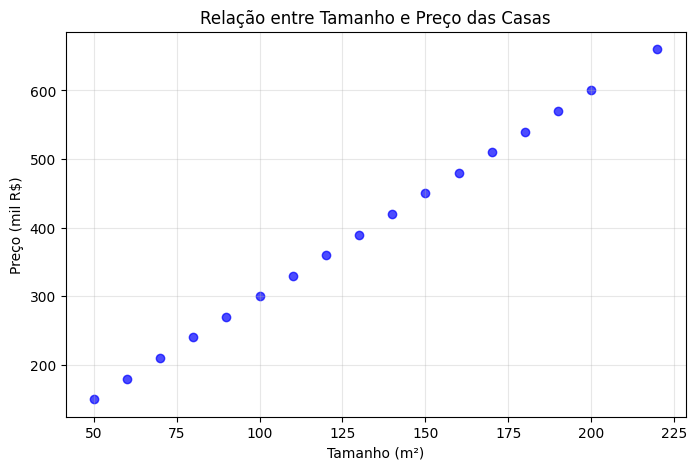


📈 Gráfico gerado! Parece que quanto maior o tamanho, maior o preço.

🔹 X (tamanho das casas): 17 registros
🔹 y (preço das casas): 17 registros

📚 Dados de treino: 10 casas
🧪 Dados de teste: 7 casas

 Modelo treinado com sucesso!

 Comparação entre valores reais e previstos:
   Tamanho (m²)  Preço Real (mil R$)  Preço Previsto (mil R$)
0            50                  150                    150.0
1            60                  180                    180.0
2           100                  300                    300.0
3           200                  600                    600.0
4           160                  480                    480.0
5           190                  570                    570.0
6           130                  390                    390.0

📊 Métricas de Avaliação:
   - R² (coeficiente de determinação): 1.0000
   - MSE (erro quadrático médio): 0.00
   - RMSE (raiz do erro quadrático médio): 0.00
   - MAE (erro absoluto médio): 0.00

 Interpretação: Modelo excelent

In [7]:
# Semana 8 - Primeiro modelo de Machine Learning
# Regressão Linear com dataset de preço de casas


# 1. Importar as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Bibliotecas importadas com sucesso!")

# 2. Criar ou carregar o dataset de casas

# Vamos criar um dataset simples manualmente (tamanho vs preço)
# Isso evita problema de download de arquivos externos

dados = {
    'tamanho_m2': [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220],
    'preco_mil': [150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570, 600, 660]
}

df = pd.DataFrame(dados)

print("\n📊 Dataset de casas carregado:")
print(df)

# 3. Visualizar os dados (opcional, mas ajuda a entender)
plt.figure(figsize=(8, 5))
plt.scatter(df['tamanho_m2'], df['preco_mil'], color='blue', alpha=0.7)
plt.xlabel('Tamanho (m²)')
plt.ylabel('Preço (mil R$)')
plt.title('Relação entre Tamanho e Preço das Casas')
plt.grid(True, alpha=0.3)
plt.show()

print("\n📈 Gráfico gerado! Parece que quanto maior o tamanho, maior o preço.")

# 4. Separar variáveis X (entrada) e y (saída)
X = df[['tamanho_m2']]  # Variável independente (previsor)
y = df['preco_mil']      # Variável dependente (alvo)

print(f"\n🔹 X (tamanho das casas): {X.shape[0]} registros")
print(f"🔹 y (preço das casas): {y.shape[0]} registros")

# 5. Dividir em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"\n📚 Dados de treino: {len(X_treino)} casas")
print(f"🧪 Dados de teste: {len(X_teste)} casas")

# 6. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print("\n Modelo treinado com sucesso!")

# 7. Fazer previsões com os dados de teste
previsoes = modelo.predict(X_teste)

print("\n Comparação entre valores reais e previstos:")
comparacao = pd.DataFrame({
    'Tamanho (m²)': X_teste.values.flatten(),
    'Preço Real (mil R$)': y_teste.values,
    'Preço Previsto (mil R$)': previsoes
})
print(comparacao)

# 8. Avaliar o modelo com métricas
r2 = r2_score(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_teste, previsoes)

print("\n📊 Métricas de Avaliação:")
print(f"   - R² (coeficiente de determinação): {r2:.4f}")
print(f"   - MSE (erro quadrático médio): {mse:.2f}")
print(f"   - RMSE (raiz do erro quadrático médio): {rmse:.2f}")
print(f"   - MAE (erro absoluto médio): {mae:.2f}")

# Interpretação simples
if r2 > 0.9:
    print("\n Interpretação: Modelo excelente! Explica mais de 90% da variação dos preços.")
elif r2 > 0.7:
    print("\n Interpretação: Modelo bom! Explica mais de 70% da variação dos preços.")
else:
    print("\n Interpretação: Modelo pode melhorar. Talvez mais dados ou outras variáveis ajudem.")

# 9. Mostrar a equação da reta (para regressão linear)
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"\n Equação da reta encontrada: Preço = {coeficiente:.2f} × Tamanho + {intercepto:.2f}")
print(f"   Significado: Cada 1m² a mais aumenta o preço em R$ {coeficiente:.2f} mil")

# 10. EXERCÍCIO PARA CASA
print("\n" + "="*50)
print("🏠 EXERCÍCIO PARA CASA")
print("="*50)

print("""
1. Execute todo o notebook e anote o valor do R².

2. Altere a proporção de treino/teste (test_size) para:
   - 0.1 (10% para teste)
   - 0.3 (30% para teste)
   - 0.4 (40% para teste)

   O que acontece com o R² em cada caso?

3. (Desafio) Tente adicionar uma nova casa ao dataset:
   Adicione uma linha com tamanho_m2 = 220 e preco_mil = 660
   Como o modelo se comporta?

4. Escreva no notebook (em texto) suas conclusões sobre:
   - O que o R² significa para este problema
   - Por que separar dados de treino e teste é importante
   - O que a equação da reta nos diz

5. Salve o notebook (Arquivo > Fazer download) e envie no repositório.
""")

print("\n✨ Bom estudo! Qualquer dúvida, me chame. ✨")

1) O resultado do R² foi de 1.0

2) Mesmo com as modificações, o R² não se altera

3) Ao adicionar a nova casa o comportamento do modelo não mudou.

4.1) O R² de 1.0 indica que a previsão bate com os valores reais

4.2) Para avaliar a capacidade de generalização do modelo diante de novos dados.

4.3) A equação da reta define a regra exata do dataset.
